# Import libs and read synthetic data

In [1]:
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
from Strong_hierarchical_lasso.SHIM import * # our library
from Create_synthetic_datasets import *




# --- Specify number of levels for each factor ---
l1, l2, l3, l4 = 6,5,3,6
levels_list=[l1,l2,l3,l4]
# Get ranges
ranges = get_ranges4(l1=l1, l2=l2, l3=l3, l4=l4)
range_main, range_2way, range_3way, range_4way = ranges

data_normal=create_basic_normal_4way()

X=data_normal["X"]
y=data_normal["y"].obs
beta_true=data_normal["beta"]["coeffs"][1:]
interc_true=data_normal["beta"]["coeffs"][0]

print(X.shape)


beta_true_main=beta_true[range_main]
beta_true_2way=beta_true[range_2way]
beta_true_3way=beta_true[range_3way]


Normal data loaded properly
(1176, 1175)


 # Shim with main init 

Intercept used: -2.2495719834249908
R² score: 0.9775755908809461


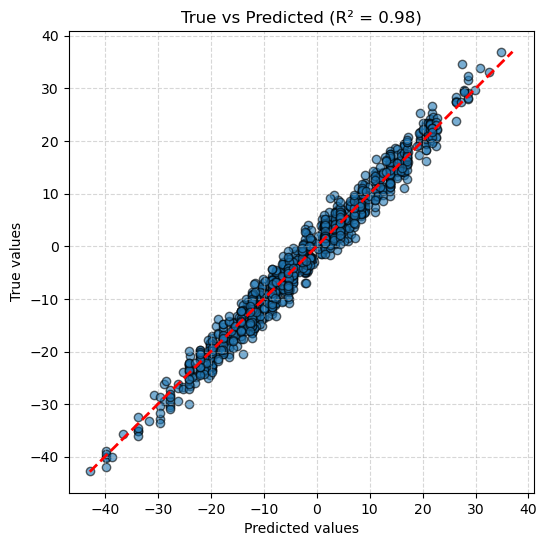

In [2]:
shim = SHIM(X=X,
            y=y,
            init_list=None,
            levels_list=levels_list,
            lambdas_list=[5e-2, 5e-2, 1e-2, 1e-1],
            response='normal'
        )

shim_fitted = shim.fit_model()
shim_fitted.R2_score(X, y, plot=True)
beta_all_shim=shim_fitted.model.beta_all
intercept_all=shim_fitted.model.intercept
beta_main_shim=beta_all_shim[range_main]
beta_2way_shim=beta_all_shim[range_2way]
beta_3way_shim=beta_all_shim[range_3way]


# Results

In [3]:
print("Main shim:")
print(beta_main_shim)

print("Main true:")
print(beta_true_main.values)

print("Two way shim:")
print(beta_2way_shim[:30])
print("Two way true")
print(beta_true_2way.values[:30])

print("Three way shim:")
print(beta_3way_shim[:60])
print("Three way true")
print(beta_true_3way.values[:60])



Main shim:
[-8.02119245  6.88012836 -0.         -0.         -5.49210774 -0.
  6.18630407  5.80817338  0.         -0.          0.         -6.17514417
 -9.87397474  0.         -4.33879875 -0.         -0.         -0.
  0.         -0.        ]
Main true:
[-8.47282891  7.43388122  0.          0.         -5.64393584  0.
  6.37285006  5.68943736  0.          0.          0.         -6.3374442
 -9.84993015  0.         -4.84102845  0.          0.          0.
  0.          0.        ]
Two way shim:
[-1.0900454   2.68193338  0.          0.          0.         -3.29731786
 -0.          0.          4.42323904  0.          0.          0.
  0.          0.          3.056754    0.2851205   0.          0.
  0.         -0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.        ]
Two way true
[-2.78036511  3.66655303  0.          0.          0.         -3.57956373
  0.          0.          4.95329541  0.          0.          0.
  0.          

# Recover coefs from last level of each factor  with identifiability conditions

In [4]:

main_names = (
    [f"A.{i}" for i in range(1, 8)] +
    [f"B.{i}" for i in range(1, 7)] +
    [f"C.{i}" for i in range(1, 5)] +
    [f"D.{i}" for i in range(1, 8)]
)


recovered_coefs=recover_coefs_with_names(main_names=main_names, beta= beta_all_shim, intercept=intercept_all, levels=levels_list)


print(recovered_coefs)

                   Values
intercept       -2.249572
A.1             -8.021192
A.2              6.880128
A.3             -0.000000
A.4             -0.000000
...                   ...
A.7:B.6:C.4:D.3 -0.000000
A.7:B.6:C.4:D.4 -0.000000
A.7:B.6:C.4:D.5 -0.000000
A.7:B.6:C.4:D.6 -0.000000
A.7:B.6:C.4:D.7 -0.000000

[2240 rows x 1 columns]
